# Network Intrusion Detection

### Predicting Normal vs. Anomalous Network Traffic with the NSL-KDD Dataset

**Authors:** Pantea, Thi, Nickolas, Nathon

---

## Project Overview

This project develops a machine learning-based network intrusion detection
system using the NSL-KDD dataset.

The objective is to classify individual network connections as either:

- **Normal**
- **Anomaly**

Four classification algorithms are evaluated:

1. L1-Regularised Logistic Regression
2. Linear Discriminant Analysis (LDA)
3. k-Nearest Neighbours (kNN)
4. Random Forest

The models are developed using stratified training and validation data and
are finally evaluated on the untouched KDDTest+ holdout set. An additional
PCA experiment is performed to investigate whether dimensionality reduction
can maintain or improve classification performance.

### Problem Definition and Success Criteria

This project addresses a binary classification problem in which individual network connections are classified as either **normal** or **anomalous**. The target variable is `binary_label`, which is created by grouping all attack types into the anomaly class while retaining normal connections as the normal class.

In network intrusion detection, failing to identify an anomalous connection may allow a malicious activity to pass through the system undetected. Therefore, **recall for the anomaly class** is treated as an important evaluation metric because it measures the proportion of actual anomalies correctly detected by the model.

However, a model that generates too many false alarms may also be impractical. For this reason, precision, specificity and F1-score are considered alongside recall. F1-score provides a balance between precision and recall, while ROC-AUC evaluates the ability of each model to distinguish between normal and anomalous connections across different classification thresholds.

The models are therefore evaluated using the following metrics:

* **Accuracy:** the overall proportion of correctly classified connections.
* **Precision:** the proportion of predicted anomalies that are actual anomalies.
* **Recall:** the proportion of actual anomalies correctly detected.
* **Specificity:** the proportion of normal connections correctly classified.
* **F1-score:** the harmonic mean of precision and recall.
* **ROC-AUC:** the ability of the model to distinguish between the two classes across different decision thresholds.

The preferred model will be the model that provides the strongest balance between anomaly recall, precision and F1-score while maintaining competitive overall accuracy and ROC-AUC.


## 1. Import Libraries

Libraries used for data processing, visualisation, preprocessing and machine learning..

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

## 2. Load the NSL-KDD Dataset

The NSL-KDD dataset contains network connection records with 41 raw
predictor variables, an attack label and a difficulty score.

KDDTrain+ is used for model development, while KDDTest+ is kept as an
independent holdout dataset for final evaluation.

In [2]:
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

train = pd.read_csv(
    "../data/nsl-kdd/KDDTrain+.txt",
    names=columns
)

test = pd.read_csv(
    "../data/nsl-kdd/KDDTest+.txt",
    names=columns
)

dataset_summary = pd.DataFrame({
    "Dataset": ["KDDTrain+", "KDDTest+"],
    "Records": [train.shape[0], test.shape[0]],
    "Columns": [train.shape[1], test.shape[1]],
    "Missing Values": [
        train.isnull().sum().sum(),
        test.isnull().sum().sum()
    ],
    "Unique Labels": [
        train["label"].nunique(),
        test["label"].nunique()
    ]
})

dataset_summary

,Dataset,Records,Columns,Missing Values,Unique Labels
0,KDDTrain+,125973,43,0,23
1,KDDTest+,22544,43,0,38


In [3]:
novel_labels = set(test["label"].unique()) - set(train["label"].unique())

print(f"Attack types present only in KDDTest+: {len(novel_labels)}")

Attack types present only in KDDTest+: 17


## 3. Create the Binary Target

The original dataset contains multiple attack categories. For binary
classification, these labels are grouped into two classes:

- **Normal**
- **Anomaly**

Any record not labelled `normal` is treated as an anomaly.

In [4]:
# Collapse the original attack labels into two classes

train["binary_label"] = train["label"].apply(
    lambda x: "normal" if x == "normal" else "anomaly"
)

test["binary_label"] = test["label"].apply(
    lambda x: "normal" if x == "normal" else "anomaly"
)

class_summary = pd.DataFrame({
    "Training (%)": train["binary_label"].value_counts(normalize=True) * 100,
    "Test (%)": test["binary_label"].value_counts(normalize=True) * 100
}).round(1)

class_summary
pd.DataFrame({
    "Feature": ["protocol_type", "service", "flag"],
    "Categories": [
        train["protocol_type"].nunique(),
        train["service"].nunique(),
        train["flag"].nunique()
    ]
})


,Feature,Categories
0,protocol_type,3
1,service,70
2,flag,11


## 4. Exploratory Data Analysis

We examine:

1. Class distribution
2. Correlations between numeric predictors
3. Distribution of important numeric features
4. Categorical variables

### 4.1 Class Distribution

The training dataset is reasonably balanced between normal and anomalous
network connections.

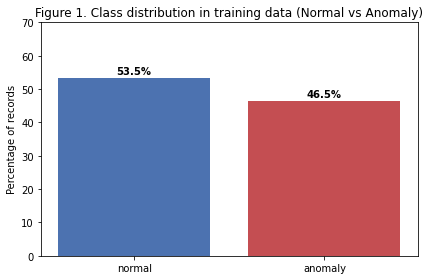

In [5]:
counts = train["binary_label"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    counts.index,
    counts.values,
    color=["#4C72B0", "#C44E52"]
)

for b, v in zip(bars, counts.values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        v + 1,
        f"{v:.1f}%",
        ha="center",
        fontweight="bold"
    )

ax.set_ylabel("Percentage of records")
ax.set_title(
    "Figure 1. Class distribution in training data (Normal vs Anomaly)"
)
ax.set_ylim(0, 70)

plt.tight_layout()
plt.savefig("figures/fig1_class_balance.png", dpi=150)
plt.show()

The training data is reasonably balanced, with slightly more normal
connections than anomalies.

### 4.2 Correlation Analysis

A correlation matrix is used to examine relationships between numerical
predictors. Highly correlated variables may contain redundant
information.

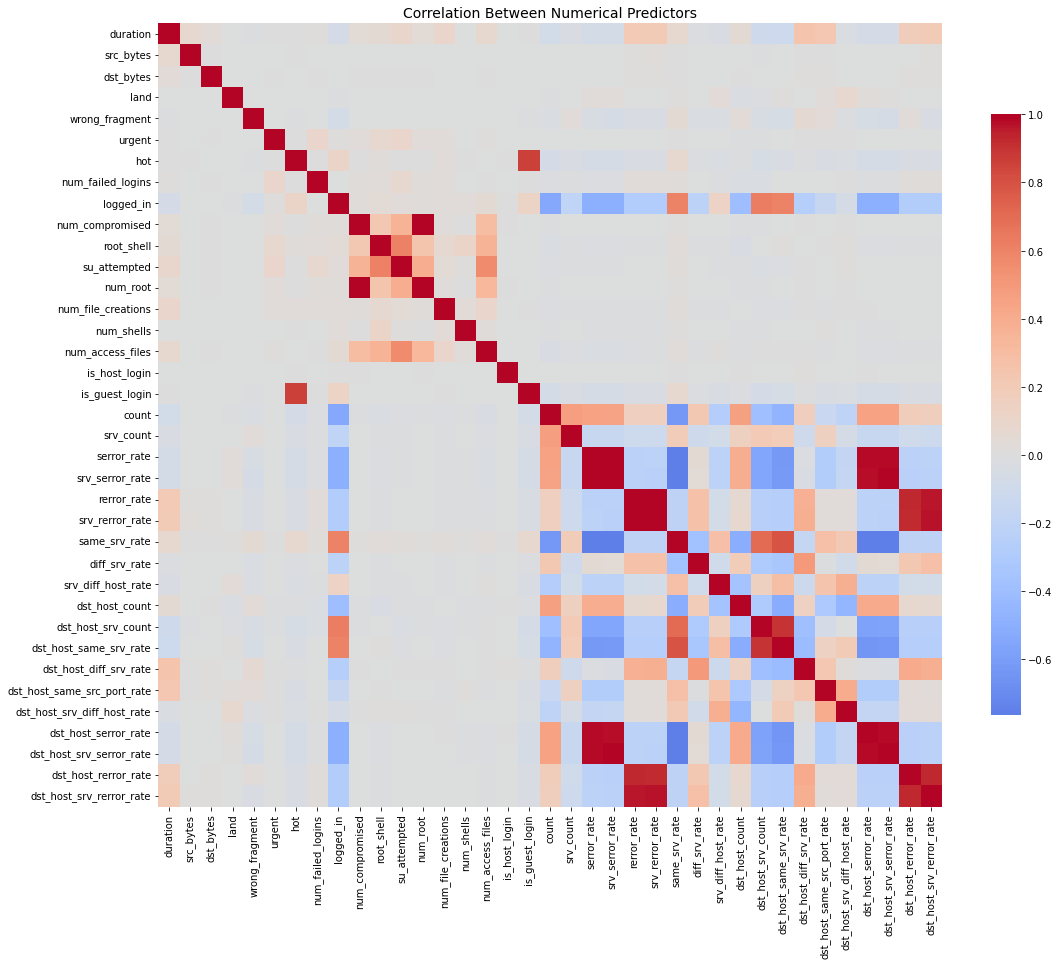

In [6]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

numeric_cols = [
    c for c in numeric_cols
    if c != "difficulty" and train[c].std() > 0
]

corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.7},
    ax=ax
)

ax.set_title(
    "Correlation Between Numerical Predictors",
    fontsize=14
)

plt.tight_layout()
plt.savefig("figures/fig2_correlation.png", dpi=150)
plt.show()

Several groups of numerical predictors are strongly correlated, particularly
the network error-rate variables. This suggests that the dataset contains
some redundant information and supports the use of feature selection later
in the pipeline.

### 4.3 Numeric Feature Distributions

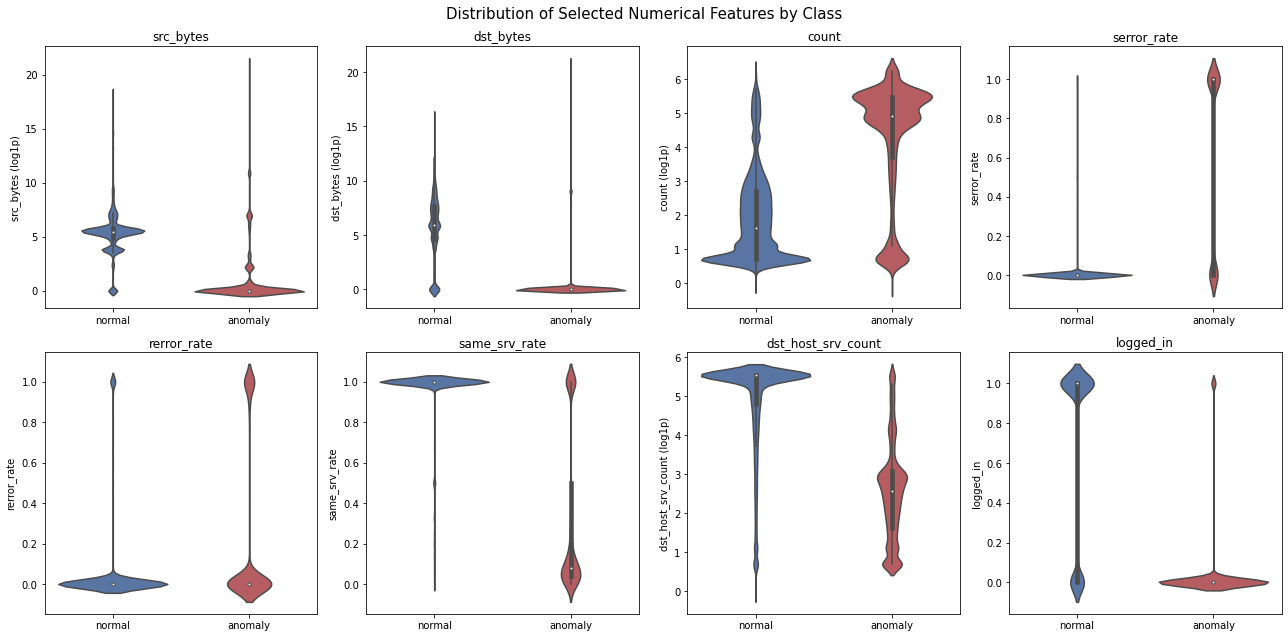

In [7]:
feats = [
    "src_bytes",
    "dst_bytes",
    "count",
    "serror_rate",
    "rerror_rate",
    "same_srv_rate",
    "dst_host_srv_count",
    "logged_in"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, f in enumerate(feats):

    data = train.copy()

    if f in [
        "src_bytes",
        "dst_bytes",
        "count",
        "dst_host_srv_count"
    ]:
        data[f] = np.log1p(data[f])
        ylabel = f"{f} (log1p)"
    else:
        ylabel = f

    sns.violinplot(
        data=data,
        x="binary_label",
        y=f,
        ax=axes[i],
        palette=["#4C72B0", "#C44E52"]
    )

    axes[i].set_title(f)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(ylabel)

plt.suptitle(
    "Distribution of Selected Numerical Features by Class",
    fontsize=15
)

plt.tight_layout()
plt.savefig("figures/fig3_violin.png", dpi=150)
plt.show()

Several numerical features show clear differences between normal and anomalous
connections. In particular, byte counts, connection counts, error rates and
service-related statistics appear to contain useful class information.

### 4.4 Categorical Features

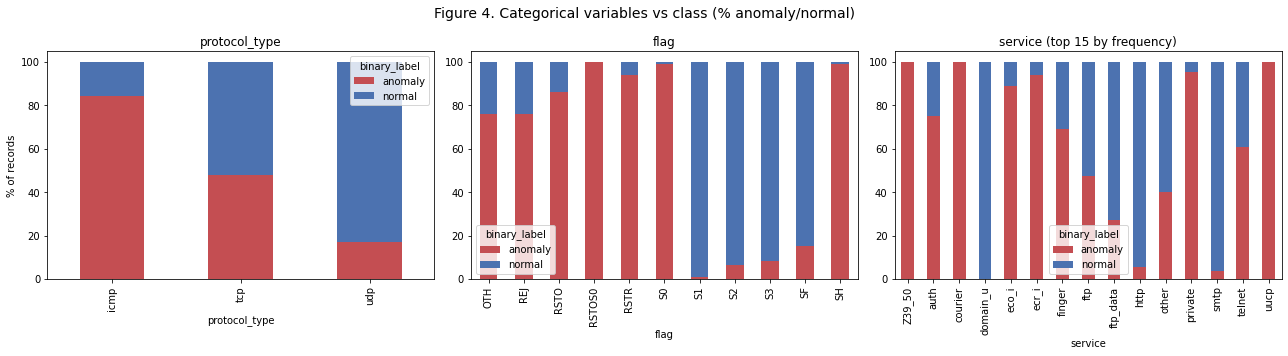

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ct = pd.crosstab(train['protocol_type'], train['binary_label'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#C44E52', '#4C72B0'])
axes[0].set_title('protocol_type')
axes[0].set_ylabel('% of records')

ct2 = pd.crosstab(train['flag'], train['binary_label'], normalize='index') * 100
ct2.plot(kind='bar', stacked=True, ax=axes[1], color=['#C44E52', '#4C72B0'])
axes[1].set_title('flag')

top_services = train['service'].value_counts().head(15).index
mask = train['service'].isin(top_services)
ct3 = pd.crosstab(train[mask]['service'], train[mask]['binary_label'], normalize='index') * 100
ct3.plot(kind='bar', stacked=True, ax=axes[2], color=['#C44E52', '#4C72B0'])
axes[2].set_title('service (top 15 by frequency)')

plt.suptitle("Figure 4. Categorical variables vs class (% anomaly/normal)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/fig4_categorical.png", dpi=150)

Categorical features also show strong class differences. Some protocols,
connection flags and services are much more strongly associated with anomalies
than others, indicating that these variables are useful predictors.

## 5. Data Preprocessing

Before modelling, the data is prepared by:

- Removing the `difficulty` metadata column
- Removing the zero-variance `num_outbound_cmds` feature
- Checking and removing duplicate training records
- Splitting KDDTrain+ into stratified training and validation sets
- Reserving KDDTest+ as the untouched final test set

In [9]:
# Create working copies
train_full = train.copy()
test_final = test.copy()

# Remove unnecessary columns
drop_cols = ["difficulty", "num_outbound_cmds"]

train_full = train_full.drop(columns=drop_cols)
test_final = test_final.drop(columns=drop_cols)

# Remove duplicate training records
before = len(train_full)
train_full = train_full.drop_duplicates()
duplicates_removed = before - len(train_full)

print(f"Duplicates removed: {duplicates_removed}")

Duplicates removed: 0


### 5.1 Training and Validation Split

KDDTrain+ is split into **80% training** and **20% validation** using
stratified sampling to preserve the class distribution.

KDDTest+ remains untouched and is used only for final model evaluation.

In [10]:
train_df, val_df = train_test_split(
    train_full,
    test_size=0.20,
    stratify=train_full["binary_label"],
    random_state=42
)

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Records": [
        len(train_df),
        len(val_df),
        len(test_final)
    ]
})

split_summary

,Dataset,Records
0,Training,100778
1,Validation,25195
2,Test,22544


> **Data leakage prevention:** Any transformation that learns from the data,
> including scaling, feature selection and PCA, is fitted using the training
> data only and then applied to the validation and test sets.

## 6. Encoding and Feature Scaling

The target is separated from the predictors. Categorical features are
one-hot encoded, and numerical features are standardised.

All learned preprocessing is based on the training data and then applied
to the validation and test sets to prevent data leakage.

In [11]:
target_col = "binary_label"

X_train = train_df.drop(columns=[target_col, "label"])
y_train = train_df[target_col]

X_val = val_df.drop(columns=[target_col, "label"])
y_val = val_df[target_col]

X_test = test_final.drop(columns=[target_col, "label"])
y_test = test_final[target_col]


### 6.1 One-Hot Encoding

The three categorical predictors—`protocol_type`, `service`, and `flag`—are
converted to dummy variables. Validation and test columns are aligned with
the training feature set.

In [12]:
cat_cols = [
    "protocol_type",
    "service",
    "flag"
]
X_train_enc = pd.get_dummies(
    X_train,
    columns=cat_cols,
    drop_first=False
)

X_val_enc = pd.get_dummies(
    X_val,
    columns=cat_cols,
    drop_first=False
)

X_test_enc = pd.get_dummies(
    X_test,
    columns=cat_cols,
    drop_first=False
)

# Make validation and test have exactly the same columns as training
X_val_enc = X_val_enc.reindex(
    columns=X_train_enc.columns,
    fill_value=0
)

X_test_enc = X_test_enc.reindex(
    columns=X_train_enc.columns,
    fill_value=0
)

print(f"Number of encoded features: {X_train_enc.shape[1]}")

Number of encoded features: 121


### 6.2 Feature Scaling

`StandardScaler` is fitted on the training data only. The fitted scaler is
then used to transform the validation and test sets.

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_enc)
X_val_scaled = scaler.transform(X_val_enc)
X_test_scaled = scaler.transform(X_test_enc)

_ = joblib.dump(scaler, "models/scaler.joblib")

## 7. Feature Selection

The one-hot encoded dataset contains **121 predictors**. Two methods are
examined for feature reduction:

1. L1-Regularised Logistic Regression for sparsity assessment
2. Random Forest feature importance for feature ranking

The final number of features is selected by comparing training and validation
error across different feature subset sizes.

### 7.1 L1-Regularised Logistic Regression

L1 regularisation is first used to assess sparsity in the encoded feature
space. At `C=0.1`, the model retains 98 of the 121 predictors, indicating
that some features may be redundant.

In [14]:
# LASSO (L1) feature selection
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.1,
    max_iter=2000,
    random_state=42
)

# Use the encoded and scaled training data
lasso.fit(X_train_scaled, y_train)

# Store coefficients with their feature names
coefs = pd.Series(
    lasso.coef_[0],
    index=X_train_enc.columns
)

print(f"LASSO (C=0.1): {(coefs != 0).sum()} / {len(coefs)} features retained")


LASSO (C=0.1): 98 / 121 features retained


### 7.2 Random Forest Feature Importance

A Random Forest is fitted to the training data to rank predictors by feature
importance. This ranking is then used to evaluate different feature subset
sizes.

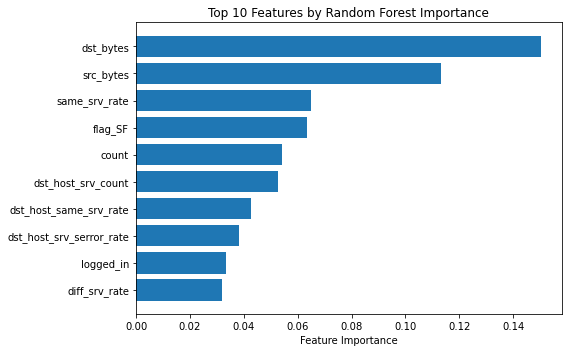

In [15]:
# Random Forest for feature importance
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train_scaled, y_train)

# Store feature importance with feature names
rf_importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False)

top_features = rf_importance.head(10).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    top_features.index,
    top_features.values
)

ax.set_xlabel("Feature Importance")
ax.set_title("Top 10 Features by Random Forest Importance")

plt.tight_layout()
plt.show()

Feature importance is learned from the training set only to prevent data leakage.

### 7.3 Selecting the Number of Features

Using the Random Forest ranking, Logistic Regression is evaluated with
different numbers of top-ranked features. Training and validation error are
compared to identify where additional features provide little improvement.

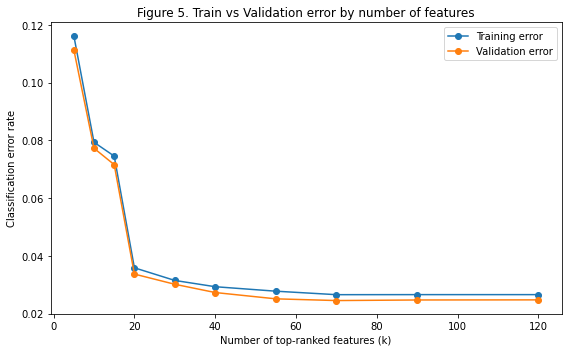

In [16]:
# Figure 5: Training vs validation error as the number of top-ranked
# Random Forest features increases

k_values = [5, 10, 15, 20, 30, 40, 55, 70, 90, 120]

train_errs = []
val_errs = []

# Random Forest feature ranking
ranked_features = rf_importance.index.tolist()

for k in k_values:

    # Select top-k features
    top_feats = ranked_features[:k]

    # Get column positions
    top_indices = [
        X_train_enc.columns.get_loc(feature)
        for feature in top_feats
    ]

    # Select the same features from training and validation sets
    X_train_k = X_train_scaled[:, top_indices]
    X_val_k = X_val_scaled[:, top_indices]

    # Logistic Regression classifier
    clf = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    clf.fit(X_train_k, y_train)

    # Training error
    train_error = 1 - accuracy_score(
        y_train,
        clf.predict(X_train_k)
    )

    # Validation error
    val_error = 1 - accuracy_score(
        y_val,
        clf.predict(X_val_k)
    )

    train_errs.append(train_error)
    val_errs.append(val_error)



# Plot Figure 5
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    k_values,
    train_errs,
    marker='o',
    label='Training error'
)

ax.plot(
    k_values,
    val_errs,
    marker='o',
    label='Validation error'
)

ax.set_xlabel("Number of top-ranked features (k)")
ax.set_ylabel("Classification error rate")
ax.set_title(
    "Figure 5. Train vs Validation error by number of features"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "figures/fig5_feature_selection.png",
    dpi=150
)

plt.show()

### 7.4 Final Feature Selection

Validation error decreases rapidly as more top-ranked features are added and
then plateaus after approximately 55–70 features. The lowest observed
validation error occurs at 70 features (0.0245), while performance with
90 features (0.0247) is nearly identical.

The **top 90 Random Forest-ranked features** are retained, reducing the
feature space from **121 to 90 predictors** while maintaining performance
comparable to the best-performing subset.

In [17]:
# Select the final top 90 Random Forest-ranked features
n_selected = 90

selected_features = rf_importance.head(n_selected).index.tolist()

# Find the corresponding column indices
selected_indices = [
    X_train_enc.columns.get_loc(feature)
    for feature in selected_features
]

# Apply the same feature selection to train, validation and test sets
X_train_selected = X_train_scaled[:, selected_indices]
X_val_selected = X_val_scaled[:, selected_indices]
X_test_selected = X_test_scaled[:, selected_indices]

print(f"Feature reduction: {X_train_scaled.shape[1]} → {n_selected}")

Feature reduction: 121 → 90


## 8. Classification Models and PCA

Four classifiers are evaluated:

1. L1-Regularised Logistic Regression
2. Linear Discriminant Analysis (LDA)
3. k-Nearest Neighbours (kNN)
4. Random Forest

Each model is evaluated using:

- The 90 selected features
- A PCA-reduced representation

The same training, validation and test partitions are used for both
representations to ensure a fair comparison.

### 8.1 Principal Component Analysis (PCA)

PCA is applied to the 90 selected predictors as an additional
dimensionality-reduction experiment.

The number of components is selected to retain at least **95% of the
cumulative explained variance**.

To prevent data leakage, PCA is fitted on the training data only and the
fitted transformation is then applied to validation and test data.

In [18]:
from sklearn.decomposition import PCA

# Fit PCA to the training data only
pca_full = PCA()

pca_full.fit(X_train_selected)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

# Find the minimum number of components needed
# to retain at least 95% of the variance
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    f"PCA reduction: 90 → {n_components_95} components "
    f"({cumulative_variance[n_components_95 - 1] * 100:.2f}% variance retained)"
)

PCA reduction: 90 → 61 components (95.29% variance retained)


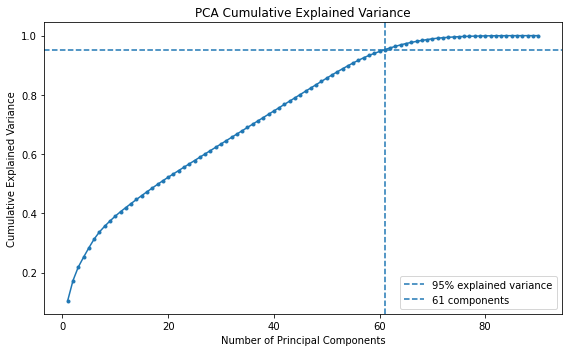

In [19]:
# Plot cumulative explained variance

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o',
    markersize=3
)

# 95% variance threshold
ax.axhline(
    y=0.95,
    linestyle='--',
    label='95% explained variance'
)

# Number of components selected
ax.axvline(
    x=n_components_95,
    linestyle='--',
    label=f'{n_components_95} components'
)

ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("PCA Cumulative Explained Variance")

ax.legend()

plt.tight_layout()

plt.savefig(
    "figures/pca_cumulative_variance.png",
    dpi=150
)

plt.show()

PCA reduces the selected feature space from **90 features to 61 principal
components**, a reduction of approximately **32.2%**, while retaining about
**95.29%** of the cumulative variance.

In [20]:
# Create the final PCA transformation

pca = PCA(
    n_components=n_components_95
)

# Fit PCA on training data and transform it
X_train_pca = pca.fit_transform(
    X_train_selected
)

# Transform validation and test data
# using the PCA fitted on training data
X_val_pca = pca.transform(
    X_val_selected
)

X_test_pca = pca.transform(
    X_test_selected
)


### 8.2 L1-Regularised Logistic Regression

The regularisation parameter `C` is tuned using validation accuracy for
both the original and PCA representations.

Candidate values:

`C = [0.001, 0.01, 0.1, 1, 10]`

In [21]:
C_values = [0.001, 0.01, 0.1, 1, 10]

lasso_results = []

print("L1 Logistic Regression - Without PCA\n")

for C in C_values:

    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=1000,
        tol=1e-3,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_selected, y_train)

    train_pred = model.predict(X_train_selected)
    val_pred = model.predict(X_val_selected)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    nonzero = np.count_nonzero(model.coef_)

    lasso_results.append({
        "C": C,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Non-zero Coefficients": nonzero
    })

lasso_results_df = pd.DataFrame(lasso_results)
lasso_results_df

L1 Logistic Regression - Without PCA



,C,Train Accuracy,Validation Accuracy,Non-zero Coefficients
0,0.001,0.969775,0.972177,25
1,0.010,0.970122,0.972375,63
2,0.100,0.971115,0.973566,88
3,1.000,0.971184,0.973606,90
4,10.000,0.971184,0.973566,90


In [22]:
lasso_pca_results = []

print("L1 Logistic Regression - With PCA\n")

for C in C_values:

    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=1000,
        tol=1e-3,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_pca, y_train)

    train_pred = model.predict(X_train_pca)
    val_pred = model.predict(X_val_pca)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    nonzero = np.count_nonzero(model.coef_)

    lasso_pca_results.append({
        "C": C,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Non-zero Coefficients": nonzero
    })

lasso_pca_results_df = pd.DataFrame(lasso_pca_results)

lasso_pca_results_df

L1 Logistic Regression - With PCA



,C,Train Accuracy,Validation Accuracy,Non-zero Coefficients
0,0.001,0.968703,0.970312,16
1,0.010,0.970450,0.972018,43
2,0.100,0.970569,0.971701,58
3,1.000,0.970549,0.971740,61
4,10.000,0.970549,0.971740,61


In [23]:
lasso_compare = pd.DataFrame({
    "C": C_values,
    "Val Accuracy — No PCA":
        lasso_results_df["Validation Accuracy"],
    "Val Accuracy — PCA":
        lasso_pca_results_df["Validation Accuracy"]
})

lasso_compare

,C,Val Accuracy — No PCA,Val Accuracy — PCA
0,0.001,0.972177,0.970312
1,0.010,0.972375,0.972018
2,0.100,0.973566,0.971701
3,1.000,0.973606,0.971740
4,10.000,0.973566,0.971740


#### L1 Logistic Regression Results

The best validation accuracy without PCA was obtained with **C=1**
(97.36%), while the best PCA model used **C=0.01** (97.20%).

PCA therefore produced very similar validation performance while reducing
the input dimensionality from 90 to 61.

In [24]:
# Store the best L1 Logistic Regression hyperparameters

best_lasso_C = 1.0
best_lasso_pca_C = 0.01


### 8.3 Linear Discriminant Analysis (LDA)

LDA is evaluated using both the 90 selected features and the 61 PCA
components to determine whether PCA can preserve performance with fewer
dimensions.

In [25]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_selected, y_train)

lda_pca_model = LinearDiscriminantAnalysis()
lda_pca_model.fit(X_train_pca, y_train)

lda_results_df = pd.DataFrame({
    "Representation": ["Without PCA", "With PCA"],
    "Inputs": [90, 61],
    "Train Accuracy": [
        accuracy_score(
            y_train,
            lda_model.predict(X_train_selected)
        ),
        accuracy_score(
            y_train,
            lda_pca_model.predict(X_train_pca)
        )
    ],
    "Validation Accuracy": [
        accuracy_score(
            y_val,
            lda_model.predict(X_val_selected)
        ),
        accuracy_score(
            y_val,
            lda_pca_model.predict(X_val_pca)
        )
    ]
})

lda_results_df

,Representation,Inputs,Train Accuracy,Validation Accuracy
0,Without PCA,90,0.965558,0.967255
1,With PCA,61,0.964645,0.967295


#### LDA Results
LDA achieved approximately **96.73% validation accuracy** with both
representations. PCA therefore reduced the dimensionality from 90 to 61
inputs without a meaningful change in validation performance.

### 8.4 k-Nearest Neighbours (kNN)

The number of neighbours is tuned using:

`k = [5, 11, 21, 51]`

To reduce computational cost, tuning is performed on a stratified subset
of **10,000 training** and **2,000 validation** observations. The same
subset is used for the PCA and non-PCA comparisons.

In [26]:
print("Train:", X_train_selected.shape)
print("Validation:", X_val_selected.shape)
print("Train:", X_train_pca.shape)
print("Validation:", X_val_pca.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

Train: (100778, 90)
Validation: (25195, 90)
Train: (100778, 61)
Validation: (25195, 61)
y_train: (100778,)
y_val: (25195,)


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Create row indices
train_indices = np.arange(len(y_train))
val_indices = np.arange(len(y_val))

# Stratified subsets for resource-safe kNN tuning
knn_train_idx, _ = train_test_split(
    train_indices,
    train_size=10000,
    stratify=y_train,
    random_state=42
)

knn_val_idx, _ = train_test_split(
    val_indices,
    train_size=2000,
    stratify=y_val,
    random_state=42
)

# Without PCA
X_knn_train = X_train_selected[knn_train_idx]
X_knn_val = X_val_selected[knn_val_idx]

# With PCA
X_knn_train_pca = X_train_pca[knn_train_idx]
X_knn_val_pca = X_val_pca[knn_val_idx]

# Targets
y_knn_train = y_train.iloc[knn_train_idx]
y_knn_val = y_val.iloc[knn_val_idx]

print("Without PCA:", X_knn_train.shape, X_knn_val.shape)
print("With PCA:", X_knn_train_pca.shape, X_knn_val_pca.shape)
print("Targets:", y_knn_train.shape, y_knn_val.shape)

Without PCA: (10000, 90) (2000, 90)
With PCA: (10000, 61) (2000, 61)
Targets: (10000,) (2000,)


In [28]:
k_values = [5, 11, 21, 51]

knn_results = []

print("kNN - Without PCA\n")

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k,
        algorithm="brute",
        metric="euclidean",
        n_jobs=1
    )

    model.fit(X_knn_train, y_knn_train)

    val_pred = model.predict(X_knn_val)

    val_acc = accuracy_score(
        y_knn_val,
        val_pred
    )

    knn_results.append({
        "Representation": "Without PCA",
        "k": k,
        "Validation Accuracy": val_acc
    })

kNN - Without PCA



In [29]:
print("\nkNN - With PCA\n")

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k,
        algorithm="brute",
        metric="euclidean",
        n_jobs=1
    )

    model.fit(X_knn_train_pca, y_knn_train)

    val_pred = model.predict(X_knn_val_pca)

    val_acc = accuracy_score(
        y_knn_val,
        val_pred
    )

    knn_results.append({
        "Representation": "With PCA",
        "k": k,
        "Validation Accuracy": val_acc
    })



kNN - With PCA



In [30]:
knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,Representation,k,Validation Accuracy
0,Without PCA,5,0.9950
1,Without PCA,11,0.9915
2,Without PCA,21,0.9915
3,Without PCA,51,0.9790
4,With PCA,5,0.9940
5,With PCA,11,0.9890
6,With PCA,21,0.9880
7,With PCA,51,0.9740


#### kNN Tuning Results

The best setting for both representations was **k=5**.

Validation accuracy was **99.50% without PCA** and **99.40% with PCA** on
the tuning subset, indicating very similar performance after dimensionality
reduction.

In [31]:
best_knn_k = 5
best_knn_pca_k = 5

### 8.5 Random Forest

Random Forest is evaluated with and without PCA to examine the effect of
dimensionality reduction on a tree-based classifier.

Because Random Forest already performs implicit feature selection, PCA is
not required for this model; it is included here for comparison.

Hyperparameter tuning uses the same stratified subset of 10,000 training
and 2,000 validation observations used for kNN.

In [35]:
import gc
n_estimators_values = [100, 200, 300]
max_features_values = ["sqrt", 0.33]

rf_results = []

for n_trees in n_estimators_values:
    for max_feat in max_features_values:

        model = RandomForestClassifier(
            n_estimators=n_trees,
            max_features=max_feat,
            random_state=42,
            n_jobs=1
        )

        model.fit(
            X_knn_train,
            y_knn_train
        )

        val_pred = model.predict(X_knn_val)

        val_acc = accuracy_score(
            y_knn_val,
            val_pred
        )

        rf_results.append({
            "Representation": "Without PCA",
            "n_estimators": n_trees,
            "max_features": max_feat,
            "Validation Accuracy": val_acc
        })

        del model
        del val_pred
        _ = gc.collect()

In [36]:
for n_trees in n_estimators_values:
    for max_feat in max_features_values:

        model = RandomForestClassifier(
            n_estimators=n_trees,
            max_features=max_feat,
            random_state=42,
            n_jobs=1
        )

        model.fit(
            X_knn_train_pca,
            y_knn_train
        )

        val_pred = model.predict(X_knn_val_pca)

        val_acc = accuracy_score(
            y_knn_val,
            val_pred
        )

        rf_results.append({
            "Representation": "With PCA",
            "n_estimators": n_trees,
            "max_features": max_feat,
            "Validation Accuracy": val_acc
        })

        del model
        del val_pred
        _ = gc.collect()

In [37]:
rf_results_df = pd.DataFrame(rf_results)
rf_results_df

,Representation,n_estimators,max_features,Validation Accuracy
0,Without PCA,100,sqrt,0.9995
1,Without PCA,100,0.33,0.9980
2,Without PCA,200,sqrt,0.9995
3,Without PCA,200,0.33,0.9980
4,Without PCA,300,sqrt,0.9995
5,Without PCA,300,0.33,0.9985
6,With PCA,100,sqrt,0.9970
7,With PCA,100,0.33,0.9945
8,With PCA,200,sqrt,0.9970
9,With PCA,200,0.33,0.9950


#### Random Forest Tuning Results

Without PCA, several configurations using `max_features="sqrt"` achieved
the same best validation accuracy of **99.95%**. The 100-tree model was
selected because additional trees did not improve validation performance.

With PCA, the best configuration used **300 trees** with
`max_features="sqrt"`, achieving **99.65%** validation accuracy.

These results are used only for hyperparameter selection. Final performance
is evaluated separately on the untouched test set.

In [38]:
# Store the selected Random Forest hyperparameters

best_rf_n_estimators = 100
best_rf_max_features = "sqrt"

best_rf_pca_n_estimators = 300
best_rf_pca_max_features = "sqrt"


## 9. Final Model Evaluation

After hyperparameter selection, the final models are trained on the training
data and evaluated on the untouched KDDTest+ holdout set.

Each classifier is evaluated with:

- The 90 selected features
- The 61 PCA components

Performance is measured using **accuracy, precision, recall, specificity,
F1-score, and ROC-AUC**.

The test set is used only for final evaluation.

## 9.1 Evaluation Function

In [39]:
def evaluate_model(model, X_test, y_test, model_name, representation):

    # Predictions
    y_pred = model.predict(X_test)

    # Probability for ROC-AUC
    if hasattr(model, "predict_proba"):
        classes = list(model.classes_)
        anomaly_index = classes.index("anomaly")
        y_prob = model.predict_proba(X_test)[:, anomaly_index]

    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)

        # Make sure larger score corresponds to anomaly
        if model.classes_[1] == "anomaly":
            y_prob = scores
        else:
            y_prob = -scores

    else:
        y_prob = None

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=["normal", "anomaly"]
    ).ravel()

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        pos_label="anomaly"
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label="anomaly"
    )

    specificity = tn / (tn + fp)

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label="anomaly"
    )

    if y_prob is not None:
        y_true_binary = (y_test == "anomaly").astype(int)
        auc = roc_auc_score(y_true_binary, y_prob)
    else:
        auc = None

    return {
        "Model": model_name,
        "Representation": representation,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,
        "ROC-AUC": auc
    }

In [40]:
final_results = []

### 9.2 L1 Logistic Regression

The L1-Regularised Logistic Regression model is now evaluated using the
61 principal components retained by PCA.

The selected regularisation parameter from the validation stage is
C = 0.01. The model is trained using the PCA-transformed training data
and evaluated on the PCA-transformed untouched test set.

In [41]:
lasso_final = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=best_lasso_C,
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    n_jobs=1
)

lasso_final.fit(X_train_selected, y_train)

final_results.append(
    evaluate_model(
        lasso_final,
        X_test_selected,
        y_test,
        "L1 Logistic Regression",
        "Without PCA"
    )
)

In [42]:
lasso_pca_final = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=best_lasso_pca_C,
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    n_jobs=1
)

lasso_pca_final.fit(X_train_pca, y_train)

final_results.append(
    evaluate_model(
        lasso_pca_final,
        X_test_pca,
        y_test,
        "L1 Logistic Regression",
        "With PCA"
    )
)

### 9.3 Linear Discriminant Analysis (LDA)

In [43]:
lda_final = LinearDiscriminantAnalysis()
lda_final.fit(X_train_selected, y_train)

final_results.append(
    evaluate_model(
        lda_final,
        X_test_selected,
        y_test,
        "LDA",
        "Without PCA"
    )
)

lda_pca_final = LinearDiscriminantAnalysis()
lda_pca_final.fit(X_train_pca, y_train)

final_results.append(
    evaluate_model(
        lda_pca_final,
        X_test_pca,
        y_test,
        "LDA",
        "With PCA"
    )
)

### 9.4 k-Nearest Neighbours (kNN)

In [44]:
def predict_knn_in_batches(model, X, batch_size=500):
    predictions = []
    probabilities = []

    for start in range(0, len(X), batch_size):
        end = min(start + batch_size, len(X))
        X_batch = X[start:end]

        predictions.append(model.predict(X_batch))
        probabilities.append(model.predict_proba(X_batch))

    return (
        np.concatenate(predictions),
        np.vstack(probabilities)
    )

In [45]:
def evaluate_knn_predictions(
    model,
    y_test,
    y_pred,
    y_prob,
    representation
):
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=["normal", "anomaly"]
    ).ravel()

    anomaly_index = list(model.classes_).index("anomaly")

    auc = roc_auc_score(
        (y_test == "anomaly").astype(int),
        y_prob[:, anomaly_index]
    )

    return {
        "Model": "kNN",
        "Representation": representation,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            pos_label="anomaly"
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            pos_label="anomaly"
        ),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(
            y_test,
            y_pred,
            pos_label="anomaly"
        ),
        "ROC-AUC": auc
    }

In [46]:
knn_final = KNeighborsClassifier(
    n_neighbors=best_knn_k,
    algorithm="brute",
    metric="euclidean",
    n_jobs=1
)

knn_final.fit(
    X_train_selected,
    y_train
)

knn_pred, knn_prob = predict_knn_in_batches(
    knn_final,
    X_test_selected
)

final_results.append(
    evaluate_knn_predictions(
        knn_final,
        y_test,
        knn_pred,
        knn_prob,
        "Without PCA"
    )
)

In [47]:
knn_pca_final = KNeighborsClassifier(
    n_neighbors=best_knn_pca_k,
    algorithm="brute",
    metric="euclidean",
    n_jobs=1
)

knn_pca_final.fit(
    X_train_pca,
    y_train
)

knn_pca_pred, knn_pca_prob = predict_knn_in_batches(
    knn_pca_final,
    X_test_pca
)

final_results.append(
    evaluate_knn_predictions(
        knn_pca_final,
        y_test,
        knn_pca_pred,
        knn_pca_prob,
        "With PCA"
    )
)

### 9.5 Random Forest

In [53]:
rf_final = RandomForestClassifier(
    n_estimators=best_rf_n_estimators,
    max_features=best_rf_max_features,
    random_state=42,
    n_jobs=1
)

rf_final.fit(X_train_selected, y_train)

final_results.append(
    evaluate_model(
        rf_final,
        X_test_selected,
        y_test,
        "Random Forest",
        "Without PCA"
    )
)

In [54]:
rf_pca_final = RandomForestClassifier(
    n_estimators=best_rf_pca_n_estimators,
    max_features=best_rf_pca_max_features,
    random_state=42,
    n_jobs=1
)

rf_pca_final.fit(X_train_pca, y_train)

final_results.append(
    evaluate_model(
        rf_pca_final,
        X_test_pca,
        y_test,
        "Random Forest",
        "With PCA"
    )
)

### 9.6 Final Results

In [55]:
final_results_df = pd.DataFrame(final_results)

metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC-AUC"
]

display_results = final_results_df.copy()

display_results[metric_cols] = (
    display_results[metric_cols] * 100
).round(2)

display_results

,Model,Representation,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC
0,L1 Logistic Regression,Without PCA,75.23,91.77,62.04,92.65,74.03,81.10
1,L1 Logistic Regression,With PCA,73.76,91.48,59.43,92.69,72.05,88.95
2,LDA,Without PCA,76.23,92.48,63.41,93.18,75.23,85.14
3,LDA,With PCA,75.17,92.41,61.44,93.33,73.80,89.17
4,kNN,Without PCA,76.89,92.18,64.91,92.72,76.18,81.81
5,kNN,With PCA,78.63,95.83,65.30,96.24,77.67,83.09
6,Random Forest,Without PCA,77.52,96.83,62.56,97.29,76.01,96.03
7,Random Forest,With PCA,79.54,96.40,66.54,96.72,78.73,95.80


### 9.7 Overall Model Comparison

Random Forest achieved the strongest overall test performance.

**Random Forest with PCA** achieved the highest accuracy (**79.54%**),
recall (**66.54%**) and F1-score (**78.73%**), providing the best balance
for anomaly detection.

**Random Forest without PCA** achieved the highest precision (**96.83%**),
specificity (**97.29%**) and ROC-AUC (**96.03%**).

PCA affected the classifiers differently. It reduced accuracy, recall and
F1-score for L1 Logistic Regression and LDA, although ROC-AUC increased for
both. In contrast, PCA improved all reported metrics for kNN and improved
accuracy, recall and F1-score for Random Forest.

Overall, PCA was not universally beneficial; its effect depended on the
classifier and evaluation metric.

## 10. Results Visualisation

### 10.1 Final Model Performance

The following figure compares the final test performance of each classifier
with and without PCA across all six evaluation metrics.

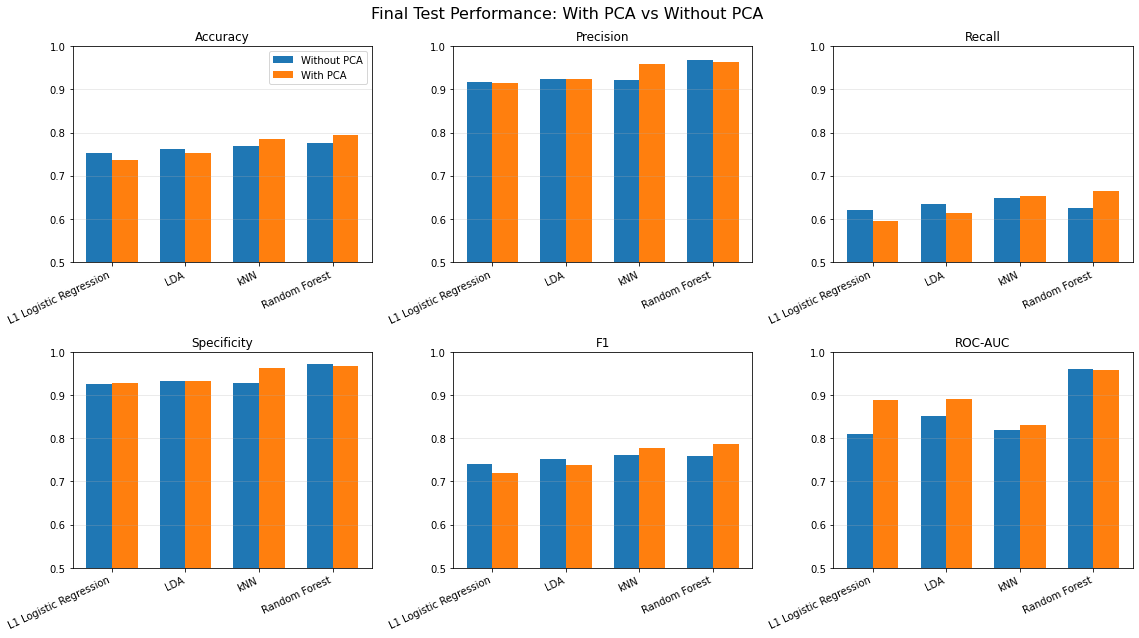

In [59]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC-AUC"
]

models = [
    "L1 Logistic Regression",
    "LDA",
    "kNN",
    "Random Forest"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):

    without_pca = []
    with_pca = []

    for model in models:

        no_pca_value = final_results_df[
            (final_results_df["Model"] == model) &
            (final_results_df["Representation"] == "Without PCA")
        ][metric].iloc[0]

        pca_value = final_results_df[
            (final_results_df["Model"] == model) &
            (final_results_df["Representation"] == "With PCA")
        ][metric].iloc[0]

        without_pca.append(no_pca_value)
        with_pca.append(pca_value)

    x = np.arange(len(models))
    width = 0.35

    ax.bar(
        x - width / 2,
        without_pca,
        width,
        label="Without PCA"
    )

    ax.bar(
        x + width / 2,
        with_pca,
        width,
        label="With PCA"
    )

    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(
        models,
        rotation=25,
        ha="right"
    )

    ax.set_ylim(0.5, 1.0)
    ax.grid(axis="y", alpha=0.3)

axes[0].legend()

fig.suptitle(
    "Final Test Performance: With PCA vs Without PCA",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "figures/final_model_pca_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Random Forest achieved the strongest overall performance. PCA improved
accuracy, recall and F1-score for Random Forest, while the non-PCA
representation achieved slightly higher precision, specificity and ROC-AUC.

PCA also improved all reported test metrics for kNN. Its effect on L1
Logistic Regression and LDA was more mixed.

### 10.2 Impact of PCA

The following table reports the change in each test metric after applying
PCA, measured in **percentage points**. Positive values indicate improvement
with PCA, while negative values indicate lower performance.

In [57]:
pca_comparison = []

for model in models:

    no_pca = final_results_df[
        (final_results_df["Model"] == model) &
        (final_results_df["Representation"] == "Without PCA")
    ].iloc[0]

    with_pca = final_results_df[
        (final_results_df["Model"] == model) &
        (final_results_df["Representation"] == "With PCA")
    ].iloc[0]

    pca_comparison.append({
        "Model": model,
        "Accuracy": (with_pca["Accuracy"] - no_pca["Accuracy"]) * 100,
        "Precision": (with_pca["Precision"] - no_pca["Precision"]) * 100,
        "Recall": (with_pca["Recall"] - no_pca["Recall"]) * 100,
        "Specificity": (with_pca["Specificity"] - no_pca["Specificity"]) * 100,
        "F1": (with_pca["F1"] - no_pca["F1"]) * 100,
        "ROC-AUC": (with_pca["ROC-AUC"] - no_pca["ROC-AUC"]) * 100
    })

pca_impact_df = pd.DataFrame(pca_comparison)

pca_impact_df.round(2)

,Model,Accuracy Change,Precision Change,Recall Change,Specificity Change,F1 Change,AUC Change
0,L1 Logistic Regression,-1.47,-0.29,-2.61,0.04,-1.98,7.85
1,LDA,-1.06,-0.07,-1.97,0.14,-1.43,4.03
2,kNN,1.74,3.65,0.39,3.52,1.49,1.28
3,Random Forest,2.02,-0.43,3.98,-0.58,2.72,-0.23


PCA had the clearest positive effect on kNN, improving all reported test
metrics.

For Random Forest, PCA increased accuracy by approximately **2.0 percentage
points**, recall by **4.0 percentage points**, and F1-score by **2.7 percentage
points**, while precision, specificity, and ROC-AUC decreased slightly.

For L1 Logistic Regression and LDA, PCA improved ROC-AUC but reduced
accuracy, recall, and F1-score.

## 11. Discussion

The results demonstrate that the effect of Principal Component Analysis (PCA)
depends on the classification algorithm.

The original feature-selection process reduced the encoded feature space to
the 90 highest-ranked features based on Random Forest feature importance.
PCA was then fitted using only the training data and reduced these 90 features
to 61 principal components while retaining approximately 95% of the cumulative
explained variance.

For L1-Regularised Logistic Regression and LDA, PCA resulted in slightly lower
accuracy, recall, and F1-score on the held-out test set. However, ROC-AUC
increased for both classifiers. This suggests that PCA improved the models'
ability to rank or separate the two classes across different classification
thresholds, but did not improve performance at the default decision threshold.

kNN benefited more clearly from PCA, with improvements across all reported
test metrics. Since kNN relies directly on distances between observations,
reducing the dimensionality may have produced a more effective representation
for distance-based classification.

Random Forest achieved the strongest overall results. With PCA, it achieved

## 12. Conclusion

This project developed and evaluated an end-to-end machine learning pipeline
for binary network intrusion detection using the NSL-KDD dataset. Four
classification algorithms were compared: L1-Regularised Logistic Regression,
Linear Discriminant Analysis (LDA), k-Nearest Neighbours (kNN), and Random
Forest.

The pipeline included data cleaning, stratified train-validation splitting,
categorical encoding, feature scaling, feature selection, model selection,
and final evaluation on the untouched KDDTest+ test set.

PCA was additionally evaluated as a dimensionality-reduction technique,
reducing the 90 selected features to 61 principal components while retaining
approximately 95% of the cumulative explained variance. Its effect varied
across classifiers: PCA improved all reported test metrics for kNN and
improved accuracy, recall, and F1-score for Random Forest, while its effect
on L1-Regularised Logistic Regression and LDA was mixed.

Random Forest provided the strongest overall performance. The PCA-based
Random Forest achieved the highest accuracy (79.54%), recall (66.54%), and
F1-score (78.73%), while the non-PCA Random Forest achieved the highest
precision (96.83%), specificity (97.29%), and ROC-AUC (96.03%).

Overall, the results demonstrate that PCA can provide a more compact
representation of network traffic data while maintaining competitive
predictive performance, but its effectiveness depends on the classifier
and the evaluation objective.